# **CHALLENGE TELCOM X PARTE 2**

🎯 **Misión**

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

## 🛠️ **PREPARACIÓN DE LOS DATOS**

### **Extracción del Archivo Tratado**

Del anterior Challenge (Parte 1) se tiene dos archicos CSV que se usaran como archivos tratados:

1. **Data.csv:** Contiene todas las columnas con la signularidad de que los datos contienen strings en las respuesta binaria (SI Y NO).
2. **Data_binaria.csv:** Los datos tiene tratamiento Binario pasando los strings a (0 Y 1).

In [2]:
import pandas as pd

In [3]:
Data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/ALURA/Challenge Telcom_X/PARTE 2/Data.csv')
Data_binaria = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/ALURA/Challenge Telcom_X/PARTE 2/Data_binaria.csv')

In [4]:
Data.head()

,ID_cliente,Permanencia,Genero_cliente,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Internet,...,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Tipo_Contrato,Preferencia_Factura,Metodo_de_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,no,yes,yes,no,one year,yes,mailed check,65.6,593.30,2.19
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40,2.00
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber optic,...,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85,2.46
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40,2.80


In [5]:
Data_binaria.head()

,ID_cliente,Permanencia,Genero_cliente,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Internet,...,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Tipo_Contrato,Preferencia_Factura,Metodo_de_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias
0,0002-ORFBO,0,female,0,1,1,9,1,0,dsl,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,male,0,0,0,9,1,1,dsl,...,0,0,0,1,month-to-month,0,mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,male,0,0,0,4,1,0,fiber optic,...,1,0,0,0,month-to-month,1,electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,male,1,1,0,13,1,0,fiber optic,...,1,0,1,1,month-to-month,1,electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,female,1,1,0,3,1,0,fiber optic,...,0,1,1,0,month-to-month,1,mailed check,83.9,267.40,2.80


### **Eliminación de Columnas Irrelevantes**

Trabajaremos con el csv Binario por facilidad númerica y estadistica necesaria de los datos

In [6]:
df = Data_binaria.copy()
columns_to_drop = ['ID_cliente'] #Elimanos la columna
df = df.drop(columns=columns_to_drop)

df.head()

,Permanencia,Genero_cliente,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Internet,Sus_Seguridad_online,...,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Tipo_Contrato,Preferencia_Factura,Metodo_de_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias
0,0,female,0,1,1,9,1,0,dsl,0,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.19
1,0,male,0,0,0,9,1,1,dsl,0,...,0,0,0,1,month-to-month,0,mailed check,59.9,542.40,2.00
2,1,male,0,0,0,4,1,0,fiber optic,0,...,1,0,0,0,month-to-month,1,electronic check,73.9,280.85,2.46
3,1,male,1,1,0,13,1,0,fiber optic,0,...,1,0,1,1,month-to-month,1,electronic check,98.0,1237.85,3.27
4,1,female,1,1,0,3,1,0,fiber optic,0,...,0,1,1,0,month-to-month,1,mailed check,83.9,267.40,2.80


### **Encoding**

In [7]:
df_encoding = df.copy()
df_encoding= pd.get_dummies(df, columns=['Genero_cliente', 'Sus_Internet', 'Tipo_Contrato', 'Metodo_de_Pago'])
pd.set_option('display.max_columns', None)
df_encoding.head()

,Permanencia,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check
0,0,0,1,1,9,1,0,0,1,0,1,1,0,1,65.6,593.30,2.19,True,False,True,False,False,False,True,False,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,0,0,1,0,59.9,542.40,2.00,False,True,True,False,False,True,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,0,1,0,0,0,1,73.9,280.85,2.46,False,True,False,True,False,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0,0,1,1,0,1,1,1,98.0,1237.85,3.27,False,True,False,True,False,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,0,1,1,0,1,83.9,267.40,2.80,True,False,False,True,False,True,False,False,False,False,False,True


Las columnas 'Genero_cliente', 'Sus_Internet', 'Tipo_Contrato' y 'Metodo_de_Pago' fueron seleccionadas porque son columnas categóricas de tipo nominal. Esto significa que sus valores son etiquetas o nombres que representan categorías distintas, sin un orden intrínseco entre ellas.

El 'one-hot encoding' resuelve esto creando nuevas columnas binarias (0 o 1) para cada categoría única en la columna original


### **Verificación de la Proporción de Cancelación (Churn)**

In [8]:
churn_proportion = df_encoding['Permanencia'].value_counts(normalize=True)
print("Proporción de clientes por estado de permanencia:")
print(churn_proportion * 100)

Proporción de clientes por estado de permanencia:
Permanencia
0             71.198569
1             25.719004
no reporta     3.082427
Name: proportion, dtype: float64


### **Balanceo de Clases**

Eliminar las filas donde 'Permanencia' es 'no reporta' del conjunto de datos, ya que no representan un estado claro de cancelación para el modelado.


In [9]:
print(f"Shape before filtering: {df_encoding.shape}")
df_encoding = df_encoding[df_encoding['Permanencia'] != 'no reporta']
print(f"Shape after filtering: {df_encoding.shape}")
df_encoding.head()

Shape before filtering: (7267, 29)
Shape after filtering: (7043, 29)


,Permanencia,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check
0,0,0,1,1,9,1,0,0,1,0,1,1,0,1,65.6,593.30,2.19,True,False,True,False,False,False,True,False,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,0,0,1,0,59.9,542.40,2.00,False,True,True,False,False,True,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,0,1,0,0,0,1,73.9,280.85,2.46,False,True,False,True,False,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0,0,1,1,0,1,1,1,98.0,1237.85,3.27,False,True,False,True,False,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,0,1,1,0,1,83.9,267.40,2.80,True,False,False,True,False,True,False,False,False,False,False,True


In [10]:
X = df_encoding.drop('Permanencia', axis=1)
y = df_encoding['Permanencia'].astype(int)

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   Cliente_Tercera_Edad  Pareja_Cliente  Dependientes_del_Cliente  \
0                     0               1                         1   
1                     0               0                         0   
2                     0               0                         0   
3                     1               1                         0   
4                     1               1                         0   

   Meses_del_Contrato  Servicio_telefonico  Multiples_lineas_telefonicas  \
0                   9                    1                             0   
1                   9                    1                             1   
2                   4                    1                             0   
3                  13                    1                             0   
4                   3                    1                             0   

   Sus_Seguridad_online  Sus_Respaldo_online  Sus_Protección_al_Dispositivo  \
0                     0       

Ahora que las características (X) y el objetivo (y) se han separado y la variable objetivo es numérica, aplicaré la técnica SMOTE para equilibrar las clases en la variable objetivo. Esto implica importar SMOTE, instanciarlo y, a continuación, remuestrear los datos.


El DataFrame contiene valores NaN. Necesito identificar y gestionar estos valores faltantes antes de aplicar SMOTE. Comprobaré si hay valores NaN en y luego los imputaré utilizando la estrategia de media para asegurar que no contenga NaN, lo cual es un requisito previo para SMOTE.

In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
import numpy as np

# Comprobar valores NaN
print("Valores NaN antes de la imputación:")
print(X.isnull().sum()[X.isnull().sum() > 0])

# Imputar valores NaN en el df utilizando la estrategia de media
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Verificar que no haya más valores NaN
print("\nValores NaN después de la imputación:")
print(X_imputed.isnull().sum()[X_imputed.isnull().sum() > 0])

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

print("\nProporción de clientes por estado de permanencia después de SMOTE:")
print(y_resampled.value_counts(normalize=True) * 100)

Valores NaN antes de la imputación:
Gasto_Total    11
dtype: int64

Valores NaN después de la imputación:
Series([], dtype: int64)

Proporción de clientes por estado de permanencia después de SMOTE:
Permanencia
0    50.0
1    50.0
Name: proportion, dtype: float64


- El conjunto de datos df_encoding contenía 7267 filas. Tras filtrar las filas donde "Permanencia" era "no reporta", se eliminaron 224 filas, reduciendo el conjunto de datos a 7043.

- Se identificó que la columna "Gasto_Total" tenía 11 valores faltantes (NaN), que posteriormente se imputaron mediante la estrategia de media.

- Tras aplicar la técnica SMOTE, la variable objetivo "Permanencia" alcanzó una distribución de clases perfectamente equilibrada, donde ambas clases (0 y 1) representan el 50% del conjunto de datos.

In [12]:
datos_post_Balanceo = X_resampled.copy()
datos_post_Balanceo['Permanencia'] = y_resampled
datos_post_Balanceo.head()

,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check,Permanencia
0,0.0,1.0,1.0,9.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30,2.19,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,0.0,0.0,0.0,9.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40,2.00,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85,2.46,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3,1.0,1.0,0.0,13.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.0,1237.85,3.27,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
4,1.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.9,267.40,2.80,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1


### **Normalización o Estandarización**

La normalización de los datos garantiza que todas las variables contribuyan en igualdad de condiciones al proceso de modelado. En modelos basados en distancia, como KNN, la magnitud de las variables influye directamente en el cálculo de la distancia entre observaciones. Si las variables no están escaladas, aquellas con mayor rango numérico pueden dominar la métrica de distancia e introducir un sesgo en la clasificación.

Al aplicar una normalización (por ejemplo, mediante MinMaxScaler), todas las variables se reescalan a un mismo rango —habitualmente entre 0 y 1—, lo que evita que aquellas con valores numéricos más altos dominen el proceso de aprendizaje. De esta manera, la magnitud original de cada variable no determina su influencia en modelos basados en distancia (como KNN) o en optimización de parámetros (como la regresión logística o las redes neuronales).

En contraste, los modelos basados en árboles no requieren normalización, ya que realizan particiones mediante umbrales y no dependen de métricas de distancia.

Identificar las columnas de tipo numérico en `X_resampled` que requieren estandarización.


In [13]:
numerical_cols = ['Meses_del_Contrato', 'Gasto_Mensual', 'Gasto_Total', 'Cuentas_Diarias']
print(f"Columnas numéricas identificadas para estandarización: {numerical_cols}")

Columnas numéricas identificadas para estandarización: ['Meses_del_Contrato', 'Gasto_Mensual', 'Gasto_Total', 'Cuentas_Diarias']


Aplicar `StandardScaler` de `sklearn.preprocessing` a las columnas numéricas identificadas


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_resampled[numerical_cols] = scaler.fit_transform(X_resampled[numerical_cols])

Para verificar la estandarización, mostraré las estadísticas descriptivas (media y desviación estándar) de las características numéricas escaladas en X_resampled.

In [15]:
print("Estadísticas descriptivas de características numéricas escaladas:")
print(datos_post_Balanceo[numerical_cols].describe().loc[['mean', 'std']])

Estadísticas descriptivas de características numéricas escaladas:
      Meses_del_Contrato  Gasto_Mensual  Gasto_Total  Cuentas_Diarias
mean            27.74069      68.031583  2049.251119         2.267729
std             23.98874      28.715000  2186.053628         0.957271


- El StandardScaler se aplicó correctamente a las columnas numéricas especificadas: Meses_del_Contrato, Gasto_Mensual, Gasto_Total y Cuentas_Diarias dentro del DataFrame X_resampled.

- Tras la estandarización, las estadísticas descriptivas confirmaron que la media de todas las columnas numéricas escaladas fue aproximadamente 0 (ex: -2,197272e-17 para Meses_del_Contrato; 3,295908e-16 para Gasto_Mensual).

- La ​​desviación estándar de todas las columnas numéricas escaladas fue aproximadamente 1 (ex: 1,000048e+00 para Meses_del_Contrato), lo que indica un escalamiento correcto.

## 🎯 **CORRELACIÓN Y SELECCIÓN DE VARIABLES**

In [16]:
datos = X_resampled.copy()
datos['Permanencia'] = y_resampled
datos.head(2)

,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check,Permanencia
0,0.0,1.0,1.0,-0.781266,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,-0.084684,-0.666050,-0.081202,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,0.0,0.0,0.0,-0.781266,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.283196,-0.689335,-0.279693,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0


### **Análisis de Correlación**

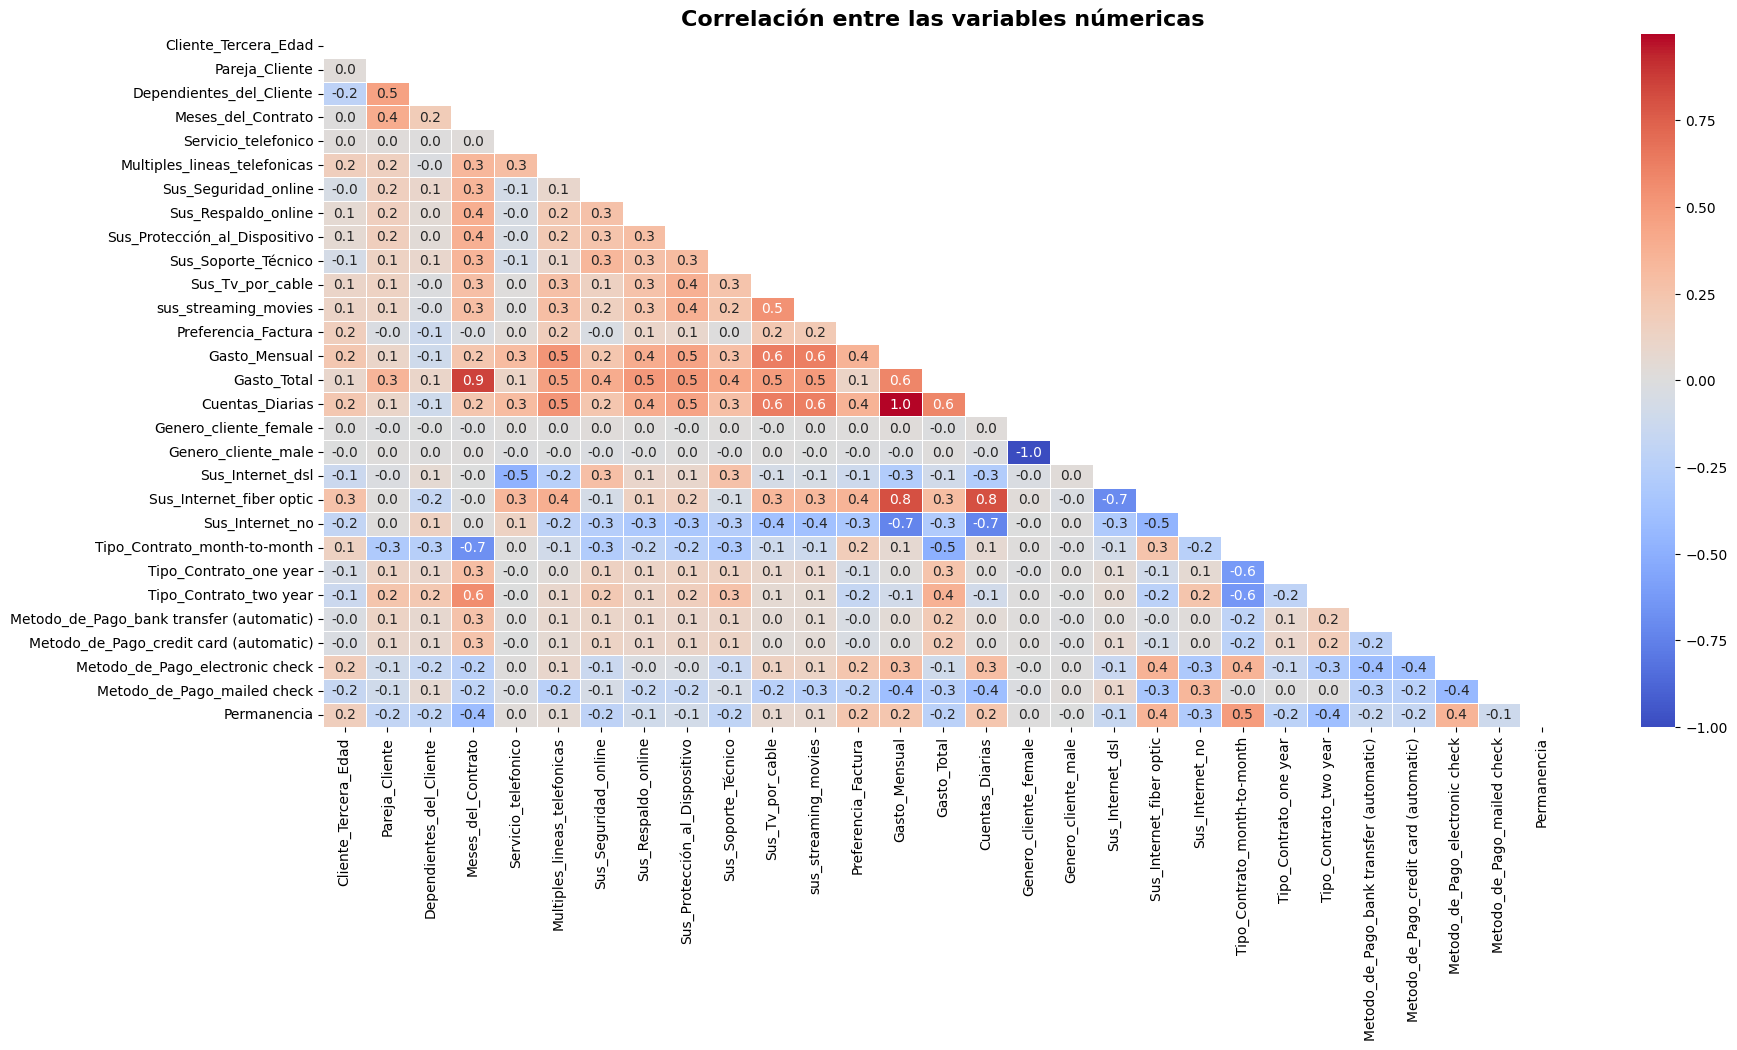

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr = datos.corr(numeric_only=True)

mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

fig, ax = plt.subplots(figsize=(20,9))
plt.title('Correlación entre las variables númericas', fontsize=16, fontweight='bold')

sns.heatmap(corr, mask=mascara, cmap='coolwarm', linewidths=0.5, annot=True, fmt='.1f', center=0)

plt.show()

Basándonos en la correlación, las columnas Multiples_lineas_telefonicas, y las columnas de género (Genero_cliente_male, Genero_cliente_female) tienen una correlación muy baja con la variable objetivo, por lo que podrían ser consideradas para su eliminación.

Además, debido a la posible multicolinealidad entre Gasto_Mensual, Gasto_Total y Meses_del_Contrato, es muy probable que una o dos de ellas sean redundantes. Esto debe comprobarse.

Recalcular y mostrar las 10 características con los valores de correlación absoluta más bajos respecto a la variable objetivo 'Permanencia' para identificar las que menos aportan al modelo.


In [18]:
correlacion_con_permanencia = datos.corr(numeric_only=True)['Permanencia'].abs()
correlacion_con_permanencia = correlacion_con_permanencia.drop('Permanencia') # Drop self-correlation

# Ordenar las correlaciones de menor a mayor
menor_correlacion = correlacion_con_permanencia.sort_values(ascending=True)

print("Las 10 columnas con la menor correlación absoluta con 'Permanencia':")
print(menor_correlacion.head(10))

Las 10 columnas con la menor correlación absoluta con 'Permanencia':
Genero_cliente_male              0.001945
Genero_cliente_female            0.001945
Servicio_telefonico              0.024214
Multiples_lineas_telefonicas     0.053129
sus_streaming_movies             0.071849
Sus_Tv_por_cable                 0.073785
Sus_Protección_al_Dispositivo    0.078654
Sus_Respaldo_online              0.098083
Metodo_de_Pago_mailed check      0.112518
Sus_Internet_dsl                 0.148542
Name: Permanencia, dtype: float64


Para evaluar la multicolinealidad entre 'Gasto_Mensual', 'Gasto_Total' y 'Meses_del_Contrato', calcularé y mostraré su matriz de correlación por pares. Esto indicará la fuerza y ​​la dirección de las relaciones lineales entre estas variables.

Correlación entre Gasto_Mensual, Gasto_Total y Meses_del_Contrato:
                    Gasto_Mensual  Gasto_Total  Meses_del_Contrato
Gasto_Mensual            1.000000     0.589145            0.234445
Gasto_Total              0.589145     1.000000            0.857279
Meses_del_Contrato       0.234445     0.857279            1.000000


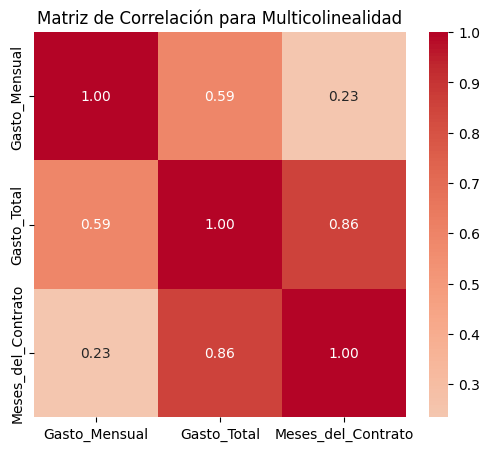

In [19]:
print("Correlación entre Gasto_Mensual, Gasto_Total y Meses_del_Contrato:")
selected_cols_multicollinearity = ['Gasto_Mensual', 'Gasto_Total', 'Meses_del_Contrato']
correlation_matrix_multicollinearity = datos[selected_cols_multicollinearity].corr(numeric_only=True)
print(correlation_matrix_multicollinearity)

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_multicollinearity, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Matriz de Correlación para Multicolinealidad')
plt.show()

Basándonos en los resultados del análisis de correlación y multicolinealidad, las columnas que se deben eliminar son:

Columnas con muy baja correlación con 'Permanencia' (Churn):

- Genero_cliente_male
- Genero_cliente_female
- Servicio_telefonico
- Multiples_lineas_telefonicas

Estas columnas tienen una correlación casi nula con la variable objetivo, lo que indica que no aportan información significativa para predecir la cancelación del cliente.

Columna con alta multicolinealidad:

- Gasto_Total

Gasto_Total está muy altamente correlacionada con Meses_del_Contrato y Gasto_Mensual. Mantener las tres puede introducir redundancia y afectar la estabilidad de algunos modelos predictivos.

In [20]:
columnas_remover = [
    'Genero_cliente_male',
    'Genero_cliente_female',
    'Servicio_telefonico',
    'Multiples_lineas_telefonicas',
    'Gasto_Total'
]

datos_tratados = datos.copy()

# Eliminar las columnas identificadas
datos_tratados = datos_tratados.drop(columns=columnas_remover)

datos_tratados.columns

Index(['Cliente_Tercera_Edad', 'Pareja_Cliente', 'Dependientes_del_Cliente',
       'Meses_del_Contrato', 'Sus_Seguridad_online', 'Sus_Respaldo_online',
       'Sus_Protección_al_Dispositivo', 'Sus_Soporte_Técnico',
       'Sus_Tv_por_cable', 'sus_streaming_movies', 'Preferencia_Factura',
       'Gasto_Mensual', 'Cuentas_Diarias', 'Sus_Internet_dsl',
       'Sus_Internet_fiber optic', 'Sus_Internet_no',
       'Tipo_Contrato_month-to-month', 'Tipo_Contrato_one year',
       'Tipo_Contrato_two year', 'Metodo_de_Pago_bank transfer (automatic)',
       'Metodo_de_Pago_credit card (automatic)',
       'Metodo_de_Pago_electronic check', 'Metodo_de_Pago_mailed check',
       'Permanencia'],
      dtype='object')

In [21]:
datos_tratados.head(2)

,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Cuentas_Diarias,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check,Permanencia
0,0.0,1.0,1.0,-0.781266,0.0,1.0,0.0,1.0,1.0,0.0,1.0,-0.084684,-0.081202,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,0.0,0.0,0.0,-0.781266,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.283196,-0.279693,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0


### **Análisis Dirigido**

#### Análisis de Variables Numéricas


Visualizar la relación de 'Meses_del_Contrato', 'Gasto_Mensual' y 'Cuentas_Diarias' con la 'Permanencia' mediante boxplots para observar la distribución de estas variables en clientes que cancelan y los que no.  

Para este caso usaremos el df hasta antes de normalizar los datos ya que no estamos haciendo modelos predictivos en este paso.


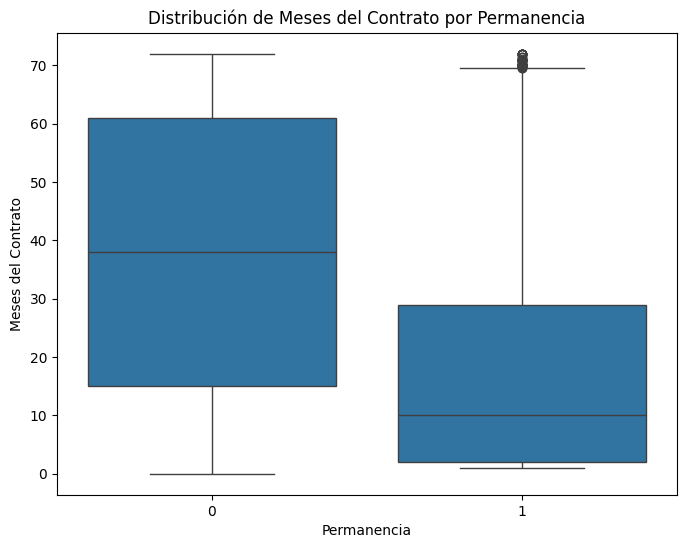

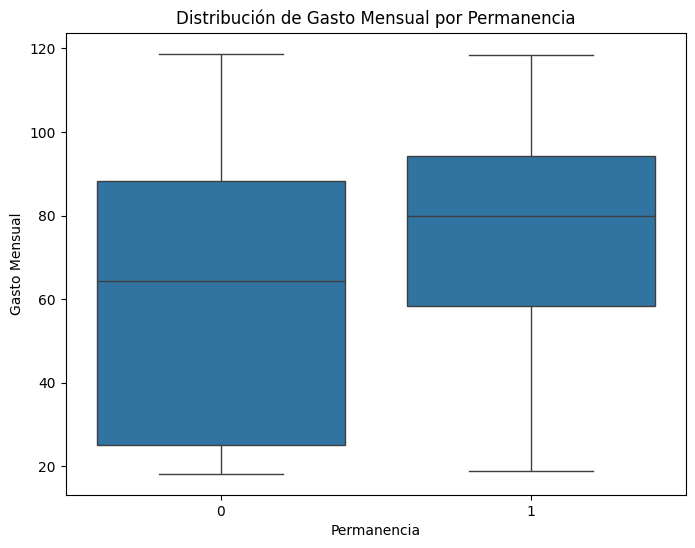

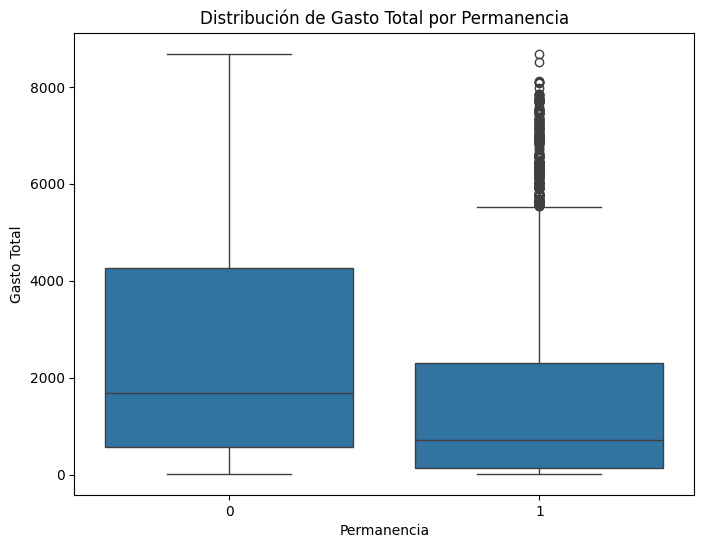

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features_for_boxplot = ['Meses_del_Contrato', 'Gasto_Mensual', 'Gasto_Total']

for col in numerical_features_for_boxplot:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Permanencia', y=col, data=datos_post_Balanceo)
    plt.title(f'Distribución de {col.replace("_", " ")} por Permanencia')
    plt.xlabel('Permanencia')
    plt.ylabel(col.replace("_", " "))
    plt.show()


**Meses_del_Contrato**

Los clientes que cancelan ('Permanencia' = 1) tienden a tener una duración de contrato significativamente menor en comparación con los clientes que no cancelan ('Permanencia' = 0). El rango intercuartílico (IQR) y la mediana para los clientes que cancelan se encuentran en valores de meses de contrato más bajos.

La duración del contrato es un factor crítico en la retención. Los clientes con contratos a corto plazo o que están en los primeros meses de su servicio son más propensos a abandonar.


**Gasto_Mensual**

Existe una tendencia donde los clientes que cancelan ('Permanencia' = 1) muestran un rango de gasto mensual ligeramente más alto en comparación con los que permanecen ('Permanencia' = 0). Aunque las distribuciones se solapan, la mediana de gasto mensual para los clientes que cancelan parece ser un poco mayor.

Esto podría indicar que los clientes con un mayor gasto mensual, posiblemente debido a servicios más complejos o paquetes premium, podrían sentirse insatisfechos si no perciben un valor adecuado por el costo, o que los altos precios pueden ser un factor para la cancelación.

**Gasto_Total**

Los clientes que cancelan ('Permanencia' = 1) tienden a tener un Gasto_Total considerablemente menor en comparación con los clientes que no cancelan ('Permanencia' = 0). Esto es esperable, ya que el gasto total es acumulativo y está fuertemente relacionado con Meses_del_Contrato.

Un menor Gasto_Total en clientes que cancelan refuerza la idea de que los clientes de corta duración (y, por lo tanto, con menor gasto acumulado) son más propensos al churn. Esto subraya la importancia de fomentar la permanencia a largo plazo para aumentar el valor de vida del cliente.


#### Análisis de Variables Categóricas

Visualizar la relación de 'Cliente_Tercera_Edad', 'Sus_Seguridad_online', 'Sus_Soporte_Técnico', y las columnas codificadas con one-hot de 'Tipo_Contrato' y 'Metodo_de_Pago' con la variable 'Permanencia' mediante countplots. Esto ayudará a entender la proporción de clientes que cancelan (churn) para cada categoría de estas variables.

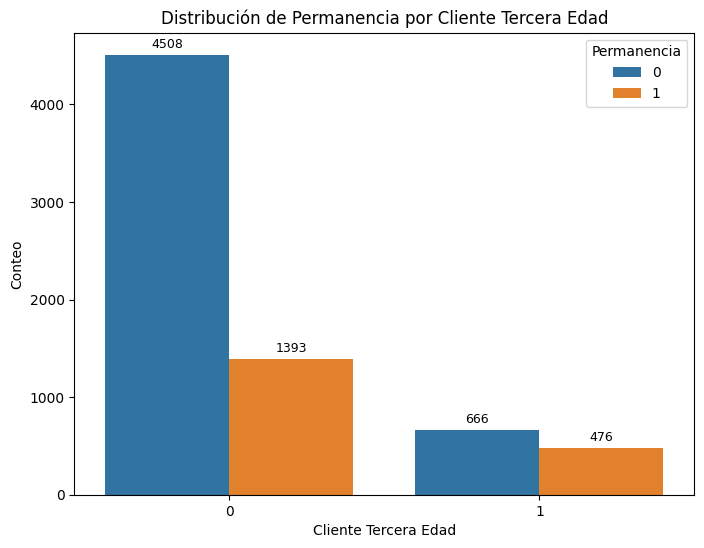

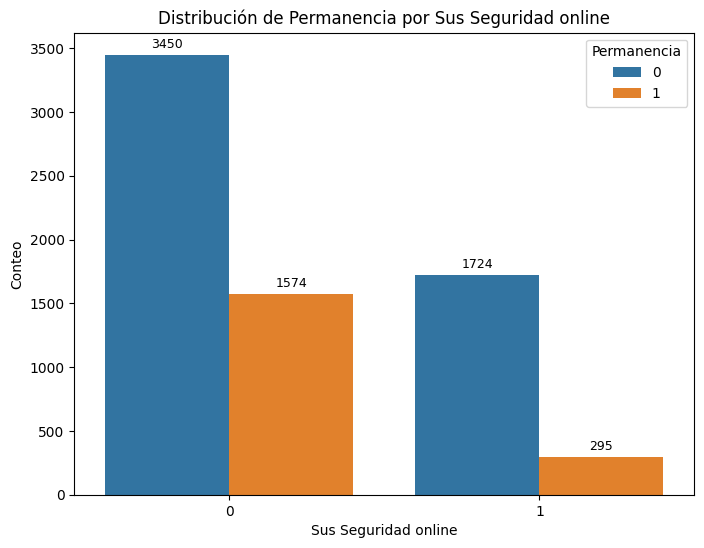

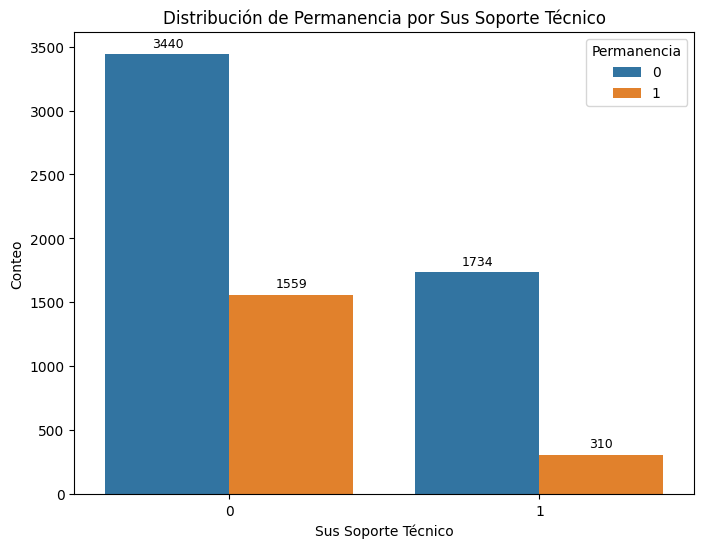

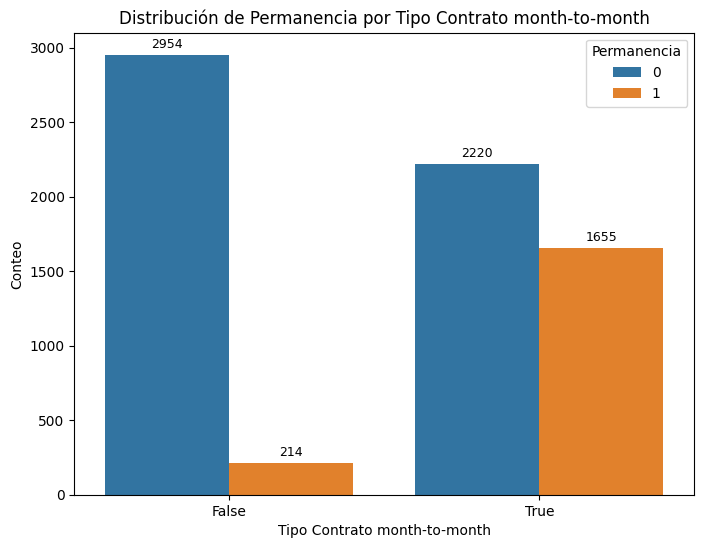

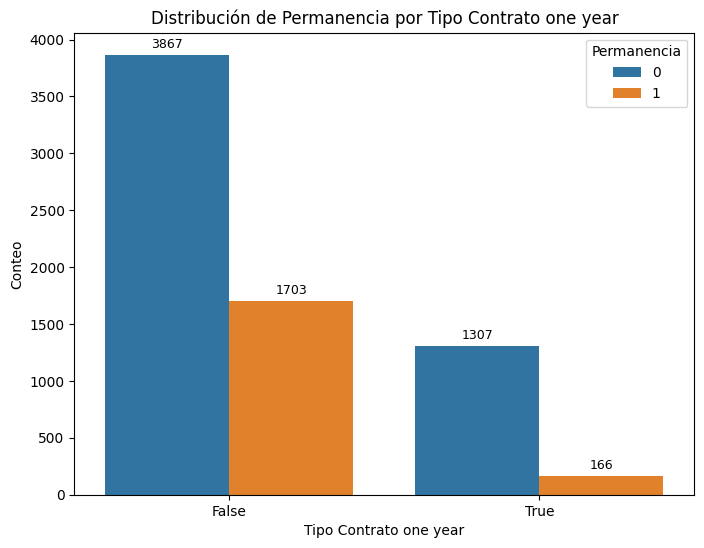

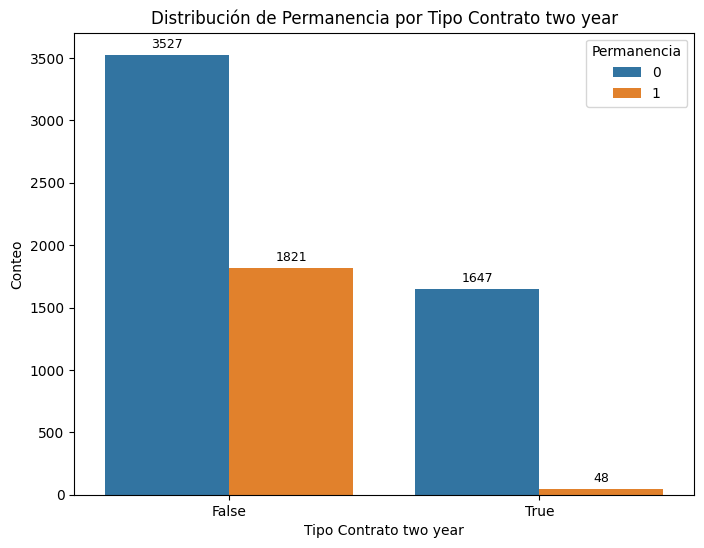

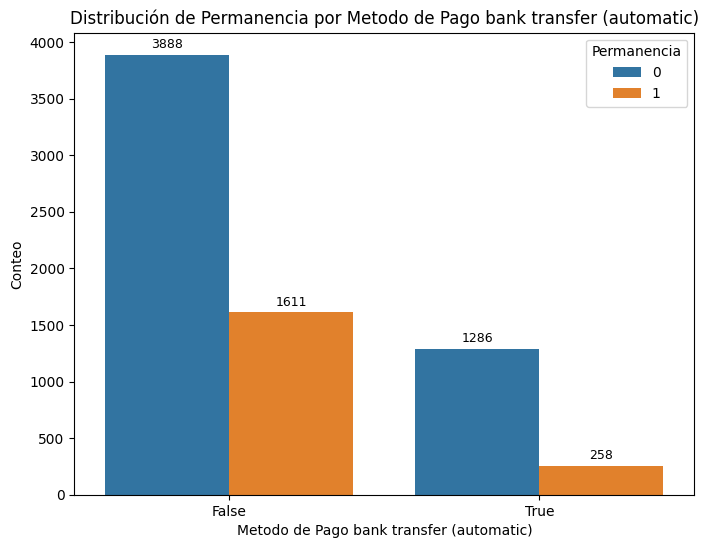

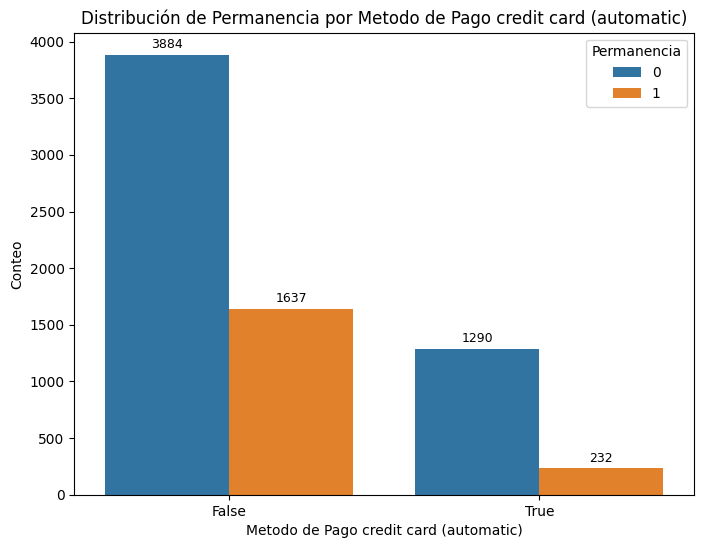

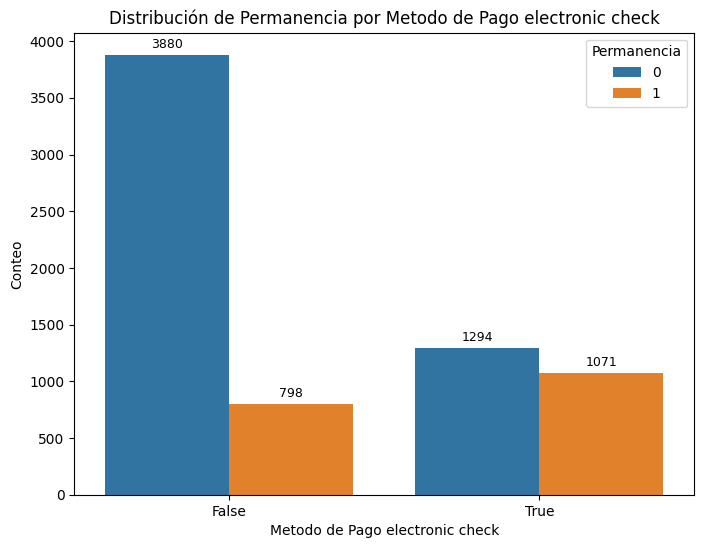

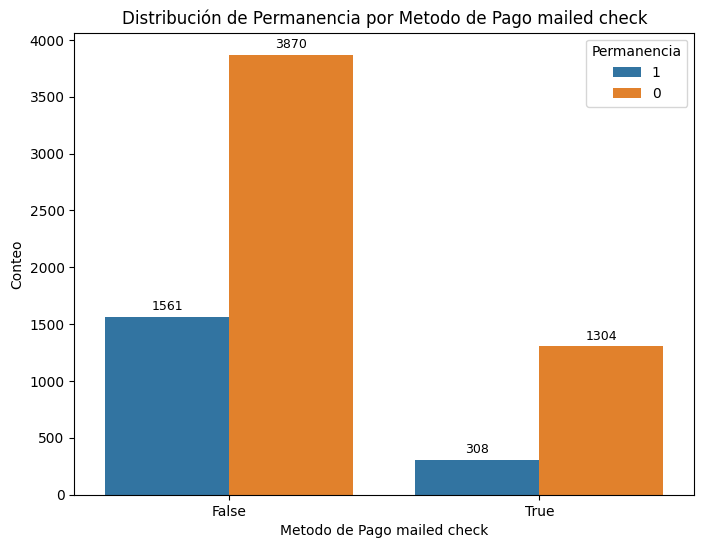

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_for_countplot = [
    'Cliente_Tercera_Edad',
    'Sus_Seguridad_online',
    'Sus_Soporte_Técnico',
    'Tipo_Contrato_month-to-month',
    'Tipo_Contrato_one year',
    'Tipo_Contrato_two year',
    'Metodo_de_Pago_bank transfer (automatic)',
    'Metodo_de_Pago_credit card (automatic)',
    'Metodo_de_Pago_electronic check',
    'Metodo_de_Pago_mailed check'
]

for col in categorical_features_for_countplot:
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=col, hue='Permanencia', data=df_encoding)
    plt.title(f'Distribución de Permanencia por {col.replace("_", " ")}')
    plt.xlabel(col.replace("_", " "))
    plt.ylabel('Conteo')

    # Añadir el total del conteo encima de cada barra
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Solo anotar barras con altura positiva
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='baseline',
                        fontsize=9, color='black', xytext=(0, 5),
                        textcoords='offset points')
    plt.show()

**Cliente Tercera Edad**

Vemos que hay una mayor cantidad de clientes que no pertencen a la tercera edad vs los que si. En cuanto a los que no son de esta categoria vemos que (4008) no permanecen, frente a 1393 que sí. Por otro lado, los que si son de la tercera edad, (666) no permanecen, frente a 476 que sí. Tanto para los clientes que son de la tercera edad como los que si, se muestra que hay mayoria en no permanencia vs los que sí.

**Seguridad Online**

Para los clientes que no contratan el servicio de seguridad online (0): 2350 no permanecen vs 1574 sí permanecen. Mientras que para los clientes que si eligen contratar este servivio Con seguridad online (1): 1724 no permanecen vs 295 sí permanecen, indicando que la seguridad online como servicio extra no aporta mucho a la permanencia de los clientes.

**Soporte Técnico**

Para los clientes que no deciden contratar el servicio de soporte técnico (0): 3440 no permanentes vs 1559 sí lo hacen. Por su parte, los cluientes que si contratan el servicio extra (1), 1734 no permanecen vs 310 sí permanecen, sugiriendo que el soporte no mejora permanencia y podría aportar a aumentar el abandono de la compañia por parte de clientes.

**Contrato Mes a Mes**

Para los clientes que no manejan su Contrato mes a mes domina la no permanencia (2554 vs 224 sí). Para aquellos que si manejan su contrato bajo esta modalidad (2220 no permanecen, 1355 sí lo hacen), observamos que entonces, dentro de los clientes que manejan este tipo de contrato hay un mayor abandono del sevicio.

**Contrato Un Año**

Para los clientes que nos manejan este tipo de contrato: 2867 no permanecen vs 1703 sí lo hacen. Para los clientes que si manejan este tipo de contrato: 1307 no permanecen vs 166 sí lo hacen, patrón similar a dos años, con retención mínima en contratos largos.

**Contrato Dos Años**

Para los clientes que nos manejan este tipo de contrato: 2327 no permanecen vs 1321 sí lo hacen. Para los clientes que si manejan este tipo de contrato: 1647 no permanecen vs 48 sí lo hacen, revelando que contratos largos tienen retención extremadamente baja.

**Pago bank transfer**

Para los clientes que no realizan su pago por banco se muestra que 3588 no permanecen vs 1511 sí lo hacen.Para los clientes que sí realizan su pago por banco se muestra alto abandono (1286 no permanecen vs 258 sí lo hacen), similar al crédito, con baja retención.

**Pago Credit Card**

Para los que no eligen el pago por tarjeta de credito, se muestran un mayor número de no permanentes (3584) sobre permanentes (1537). Para los que si escogen este metodo de pago, hay más abandono del servicio (1294 no permanencen vs 223 sí permanecen), sugiriendo que este método no favorece la retención, ya que se observa que no es un metodo de pago que sea preferido por la gran mayoria de clientes.

**Pago Cheque Electrónico**

Para los que no eligen el pago por cheque electrónico se tiene 1380 no permanecen vs 798 sí lo hacen. Para los que sí eligen el pago por cheque electrónico, equilibra (1274 no permanecen, 1071 sí lo hacen), mostrando retención moderada en este metodo de pago.

**Pago Cheque Postal**

Para los que no eligen el pago  por cheque postal, 1541 no permanecen vs 3870 sí hacen, alta retención. Para los que sí eligen este metodo se invierte (1904 no vs 308 sí), destacando cheques postales como factor de abando del servicio.



## 🤖 **MODELADO PREDICTIVO**

In [33]:
columnas_remover = [
    'Genero_cliente_male',
    'Genero_cliente_female',
    'Servicio_telefonico',
    'Multiples_lineas_telefonicas',
    'Gasto_Total'
]

datos_Balanceo = datos_post_Balanceo.copy()

# Eliminar las columnas identificadas
datos_Balanceo = datos_Balanceo.drop(columns=columnas_remover)

datos_Balanceo.columns

Index(['Cliente_Tercera_Edad', 'Pareja_Cliente', 'Dependientes_del_Cliente',
       'Meses_del_Contrato', 'Sus_Seguridad_online', 'Sus_Respaldo_online',
       'Sus_Protección_al_Dispositivo', 'Sus_Soporte_Técnico',
       'Sus_Tv_por_cable', 'sus_streaming_movies', 'Preferencia_Factura',
       'Gasto_Mensual', 'Cuentas_Diarias', 'Sus_Internet_dsl',
       'Sus_Internet_fiber optic', 'Sus_Internet_no',
       'Tipo_Contrato_month-to-month', 'Tipo_Contrato_one year',
       'Tipo_Contrato_two year', 'Metodo_de_Pago_bank transfer (automatic)',
       'Metodo_de_Pago_credit card (automatic)',
       'Metodo_de_Pago_electronic check', 'Metodo_de_Pago_mailed check',
       'Permanencia'],
      dtype='object')

In [34]:
from sklearn.model_selection import train_test_split

# Separar las características (X) y la variable objetivo (y)
X = datos_Balanceo.drop('Permanencia', axis=1)
y = datos_Balanceo['Permanencia']

# Dividir el conjunto de datos en entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Dimensiones de los conjuntos de entrenamiento:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nDimensiones de los conjuntos de prueba:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Dimensiones de los conjuntos de entrenamiento:
X_train: (7243, 23)
y_train: (7243,)

Dimensiones de los conjuntos de prueba:
X_test: (3105, 23)
y_test: (3105,)


### **Creación de Modelos**

**Modelo de referencia - Baseline**

In [35]:
from sklearn.dummy import DummyClassifier

In [36]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)

dummy.score(X_test, y_test)

0.4885668276972625

**Árbol de Decisión**

In [31]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
modelo_arbol = DecisionTreeClassifier(random_state =5)
modelo_arbol.fit(X_train, y_train)

DecisionTreeClassifier(random_state=5)

In [38]:
modelo_arbol.predict(X_test)

array([1, 0, 0, ..., 1, 0, 0])

In [39]:
modelo_arbol.score(X_test, y_test)

0.8035426731078905

In [40]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [41]:
valores_columnas = ['Cliente_Tercera_Edad', 'Pareja_Cliente', 'Dependientes_del_Cliente',
       'Meses_del_Contrato', 'Sus_Seguridad_online', 'Sus_Respaldo_online',
       'Sus_Protección_al_Dispositivo', 'Sus_Soporte_Técnico',
       'Sus_Tv_por_cable', 'sus_streaming_movies', 'Preferencia_Factura',
       'Gasto_Mensual', 'Cuentas_Diarias', 'Sus_Internet_dsl',
       'Sus_Internet_fiber optic', 'Sus_Internet_no',
       'Tipo_Contrato_month-to-month', 'Tipo_Contrato_one year',
       'Tipo_Contrato_two year', 'Metodo_de_Pago_bank transfer (automatic)',
       'Metodo_de_Pago_credit card (automatic)',
       'Metodo_de_Pago_electronic check', 'Metodo_de_Pago_mailed check',
       'Permanencia']

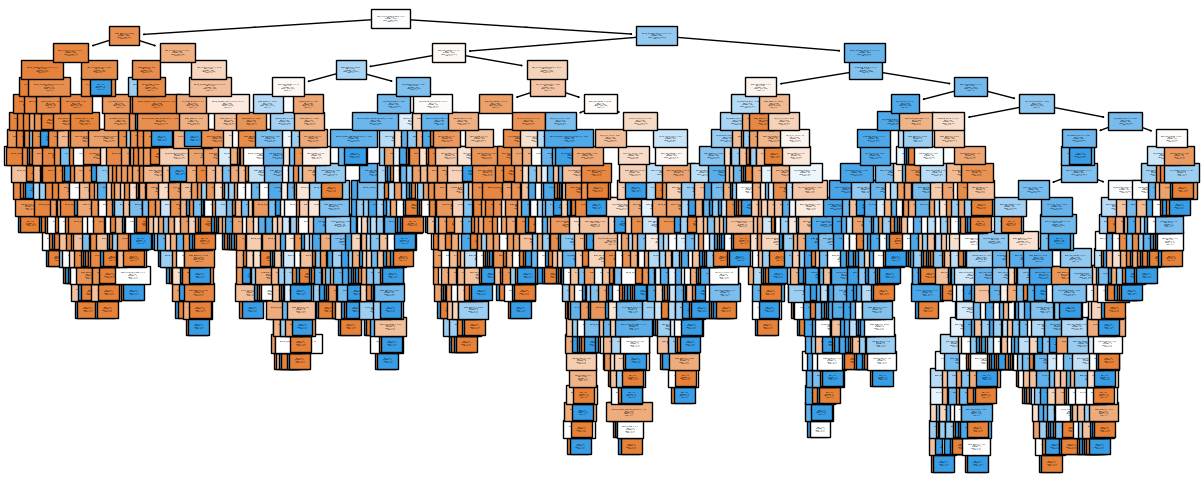

In [42]:
plt.figure(figsize = (15, 6))
plot_tree(modelo_arbol, filled = True, class_names = ['no', 'si'], fontsize = 1, feature_names = valores_columnas);

**KNN**

In [45]:
from sklearn.preprocessing import MinMaxScaler
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
0,0.829821,0.000000,0.000000,0.027778,0.000000,0.0,0.000000,0.0,1.0,1.0,1.000000,0.757118,0.755795,0.0,1.0,0.0,1.0,0.0,0.0,0.000000,0.0,1.000000,0.000000
1,0.000000,0.000000,0.322848,0.013889,0.322848,0.0,0.677152,0.0,0.0,0.0,0.322848,0.550072,0.549254,0.0,1.0,0.0,1.0,0.0,0.0,0.677152,0.0,0.000000,0.322848
2,0.000000,0.000000,0.000000,0.666667,0.000000,1.0,0.000000,0.0,0.0,0.0,0.000000,0.566169,0.567164,0.0,1.0,0.0,0.0,1.0,0.0,0.000000,0.0,1.000000,0.000000
3,1.000000,1.000000,0.000000,0.569444,1.000000,0.0,1.000000,0.0,0.0,0.0,1.000000,0.651741,0.650746,0.0,1.0,0.0,1.0,0.0,0.0,1.000000,0.0,0.000000,0.000000
4,1.000000,0.000000,0.000000,0.527778,1.000000,1.0,0.000000,0.0,0.0,0.0,1.000000,0.387065,0.385075,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,1.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7238,0.000000,1.000000,1.000000,0.930556,1.000000,0.0,0.000000,1.0,0.0,0.0,0.000000,0.173632,0.173134,1.0,0.0,0.0,0.0,0.0,1.0,0.000000,1.0,0.000000,0.000000
7239,0.000000,0.000000,0.000000,0.013889,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.008955,0.008955,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,0.000000,1.000000
7240,0.000000,0.000000,0.000000,0.013889,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.012935,0.011940,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,0.000000,1.000000
7241,0.000000,1.000000,1.000000,0.722222,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.065174,0.065672,0.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.0,0.000000,1.000000


In [43]:
from sklearn.neighbors import KNeighborsClassifier

In [44]:
knn = KNeighborsClassifier()

In [46]:
knn.fit(X_train_normalizado, y_train)

KNeighborsClassifier()

In [47]:
X_test_normalizado = normalizacion.transform(X_test)

In [48]:
knn.score(X_test_normalizado, y_test)

0.7697262479871175

### **Evaluación de los Modelos**

In [49]:
print(f'Exactitud Dummy: {dummy.score(X_test, y_test)}')
print(f'Exactitud modelo_arbol: {modelo_arbol.score(X_test, y_test)}')
print(f'Exactitud KNN: {knn.score(X_test_normalizado, y_test)}')

Exactitud Dummy: 0.4885668276972625
Exactitud modelo_arbol: 0.8035426731078905
Exactitud KNN: 0.7697262479871175


In [50]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

y_dummy_predict = dummy.predict(X_test)
y_arbol_predict = modelo_arbol.predict(X_test)
y_knn_predict = knn.predict(X_test_normalizado)


resultados = (pd.DataFrame({
    'Modelo' : ['Dummy', 'Decision Tree', 'KNN'],
    'Accuracy':[
        accuracy_score(y_test, y_dummy_predict),
        accuracy_score(y_test, y_arbol_predict),
        accuracy_score(y_test, y_knn_predict)
    ],
    'Recall' : [
        recall_score(y_test, y_dummy_predict),
        recall_score(y_test, y_arbol_predict),
        recall_score(y_test, y_knn_predict)
    ],
    'Precision' : [
        precision_score(y_test, y_dummy_predict),
        precision_score(y_test, y_arbol_predict),
        precision_score(y_test, y_knn_predict),
    ],
    'F1': [
        f1_score(y_test, y_dummy_predict),
        f1_score(y_test, y_arbol_predict),
        f1_score(y_test, y_knn_predict)
    ]
})).round(2)


resultados

,Modelo,Accuracy,Recall,Precision,F1
0,Dummy,0.49,1.00,0.49,0.66
1,Decision Tree,0.80,0.79,0.81,0.80
2,KNN,0.77,0.85,0.72,0.78


**Matriz de Confusión**

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

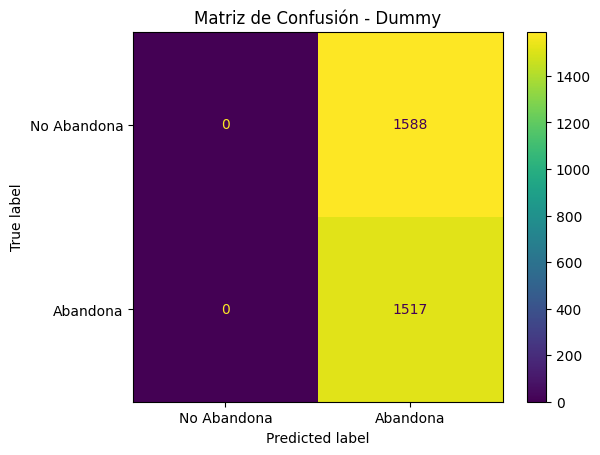

In [55]:
ConfusionMatrixDisplay.from_predictions(y_test, y_dummy_predict, display_labels=["No Abandona", "Abandona"])
plt.title('Matriz de Confusión - Dummy')
plt.show()

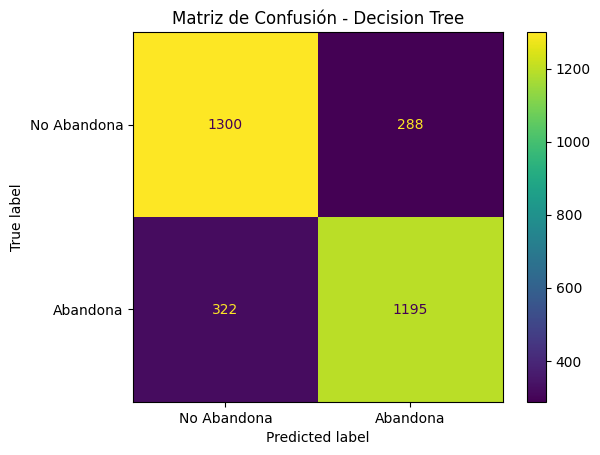

In [56]:
ConfusionMatrixDisplay.from_predictions(y_test,y_arbol_predict, display_labels=["No Abandona", "Abandona"])

plt.title("Matriz de Confusión - Decision Tree")
plt.show()

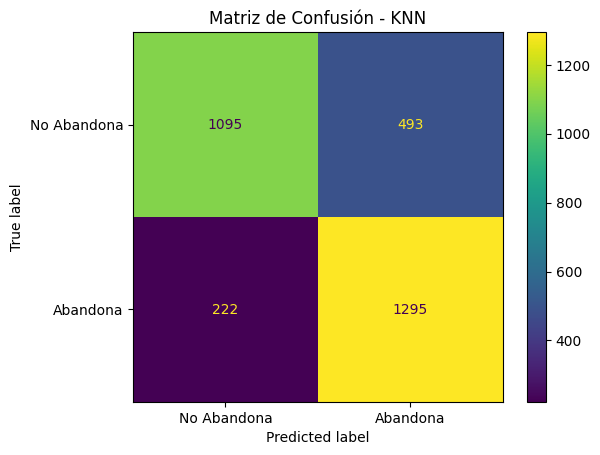

In [57]:
ConfusionMatrixDisplay.from_predictions(y_test, y_knn_predict, display_labels=["No Abandona", "Abandona"])

plt.title("Matriz de Confusión - KNN")
plt.show()
